In [2]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from transformers import GPT2Model, GPT2Tokenizer, BertTokenizer, BertModel
import torch

# Position embeddings

In [3]:
gpt2_model = GPT2Model.from_pretrained("gpt2")
position_embeddings = gpt2_model.wpe.weight.detach().numpy()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
position_embeddings.shape

# 1024 = the maximum number of positions (tokens) the model can handle. Index 0 is the 1st token, index 176 is the 177th token, etc.
# 768 = the size of each position vector — 768 numbers that together encode "what it means to be at this position"

(1024, 768)

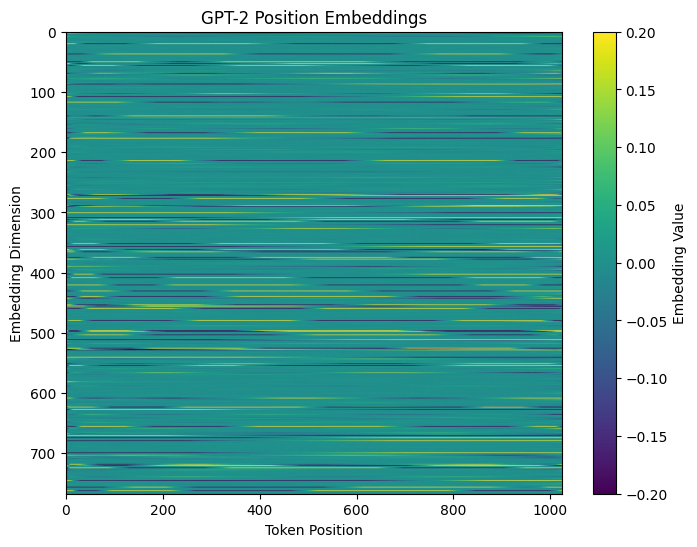

In [8]:
# visualize the matrix
plt.figure(figsize=(8, 6))
plt.imshow(position_embeddings.T, aspect='auto', cmap='viridis', vmin=-0.2, vmax=0.2)
plt.colorbar(label='Embedding Value')
plt.title('GPT-2 Position Embeddings')
plt.xlabel('Token Position')
plt.ylabel('Embedding Dimension')
plt.show()

In [49]:
pos_idx

338

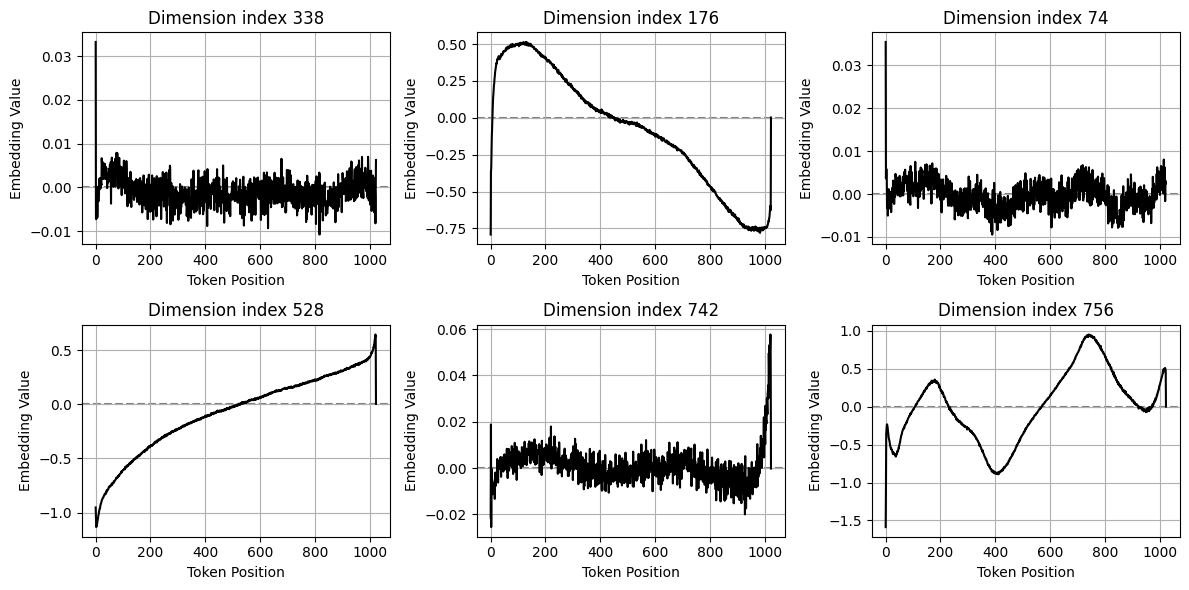

In [ ]:
# plot random positions
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
np.random.seed(13)  # for reproducibility

for ax in axes.flatten():
    dimension_idx = np.random.randint(0, position_embeddings.shape[1]) # random dimension index
    ax.plot(position_embeddings[:, dimension_idx], "k")
    ax.axhline(0, color='gray', linestyle='--', zorder=-3)
    ax.set_title(f'Dimension index {dimension_idx}')
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Embedding Value')
    ax.grid()
plt.tight_layout()
plt.show()

# we can see there are from low to high frequency patterns in the position embeddings, which are designed to help the model learn
# the relative positions of tokens in a sequence.

# the position embedding 176, for example, has low frequency pattern. 
# Imagine GPT-2 is processing a sequence of 1024 tokens, and when it is processing a token and it wants to know 
# "am I early or late in the sequence?" It can look at dimension 176's value and reason about it:
#"This value is high (~0.5) → I must be near the beginning"
#"This value is near zero → I must be somewhere in the middle"
#"This value is very negative → I must be near the end"

# Smooth dimensions (like dim 176) → good at telling apart distant positions. Position 50 vs position 900?
#  Easy, the values are very different. But position 50 vs position 51? Both have almost the same value — useless for distinguishing them.
# Noisy dimensions (like dim 74) → good at telling apart nearby positions. Because they oscillate rapidly, position 50 and position 51 can 
# have very different values. But they're terrible at global structure — position 51 and position 800 might happen to have similar values too.

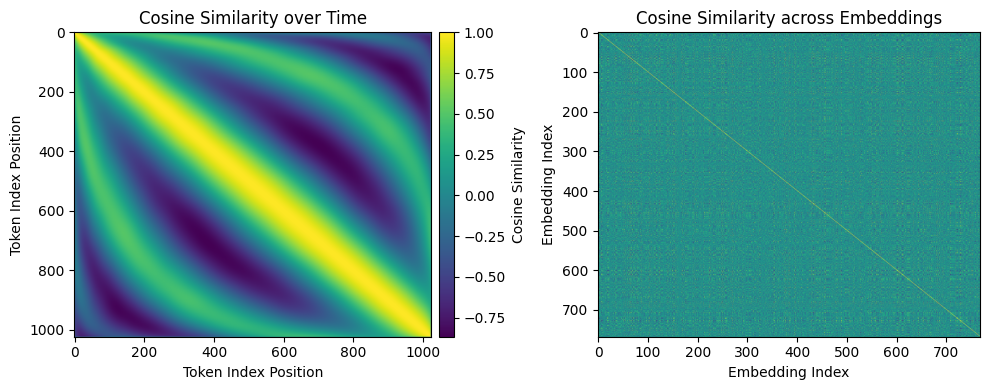

In [ ]:
# normalize the position embeddings for "time series" (token position)
norm_position_time = position_embeddings / np.linalg.norm(position_embeddings, axis=1, keepdims=True)
cosine_sim_time = norm_position_time @ norm_position_time.T

# normalize the position embeddings for "feature space" (embedding dimension)
norm_position_feature = position_embeddings / np.linalg.norm(position_embeddings, axis=0, keepdims=True)
cosine_sim_feature = norm_position_feature.T @ norm_position_feature # we do the transpose first to get the cosine similarity between features instead of positions

# draw the images
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cosine_sim_time, aspect='auto', cmap='viridis')
# show one color bar for both images
cbar = fig.colorbar(axes[0].imshow(cosine_sim_time, aspect='auto', cmap='viridis'), ax=axes[0], fraction=0.046, pad=0.02)
cbar.set_label('Cosine Similarity')
axes[0].set_title('Cosine Similarity over Time')
axes[0].set_xlabel('Token Index Position')
axes[0].set_ylabel('Token Index Position')
axes[1].imshow(cosine_sim_feature, aspect='auto', cmap='viridis')
axes[1].set_title('Cosine Similarity across Embeddings')
axes[1].set_xlabel('Embedding Index')
axes[1].set_ylabel('Embedding Index')
plt.tight_layout()
plt.show()

# in the cosine similarity for embeddings we can't see any clear pattern, in fact, they are very close to zero, 
# which means that the embedding dimensions are designed to be orthogonal to each other, and therefore they are not correlated.
# In other words, each embedding dimension captures a different aspect of embedding, independent and unique from the others.

# while in the cosine similarity over time / token position. We can see a clear pattern of diagonal lines, which indicates the tendencies
# of embeddings to be more similar to their nearby positions, and less similar to distant positions. This is because the position embeddings 
# are designed to capture the relative positions of tokens in a sequence, and therefore they have a strong correlation with their nearby positions.

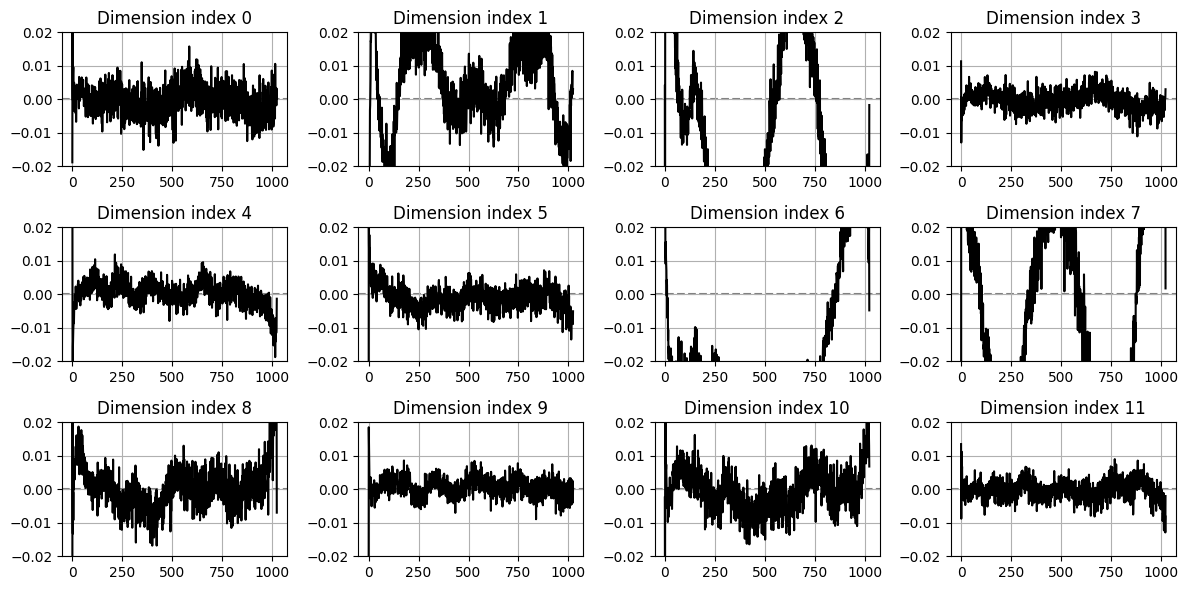

In [ ]:
dimension_indexes = np.arange(0, 12)
fig, axes = plt.subplots(3, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    dimension_idx = dimension_indexes[i]
    ax.plot(position_embeddings[:, dimension_idx], "k")
    ax.axhline(0, color='gray', linestyle='--', zorder=-3)
    ax.set_title(f'Dimension index {dimension_idx}')
    ax.set_ylim(-0.02, 0.02)
    ax.grid()
plt.tight_layout()
plt.show()

# we can see that for example index 0 is highly correlated with index 3, 4, 5, 8, 9, 10 and 11. That is what we were visualizing in the past example.
# however, likely if we go into higher dimension indexes they will look different from dimension index 0.

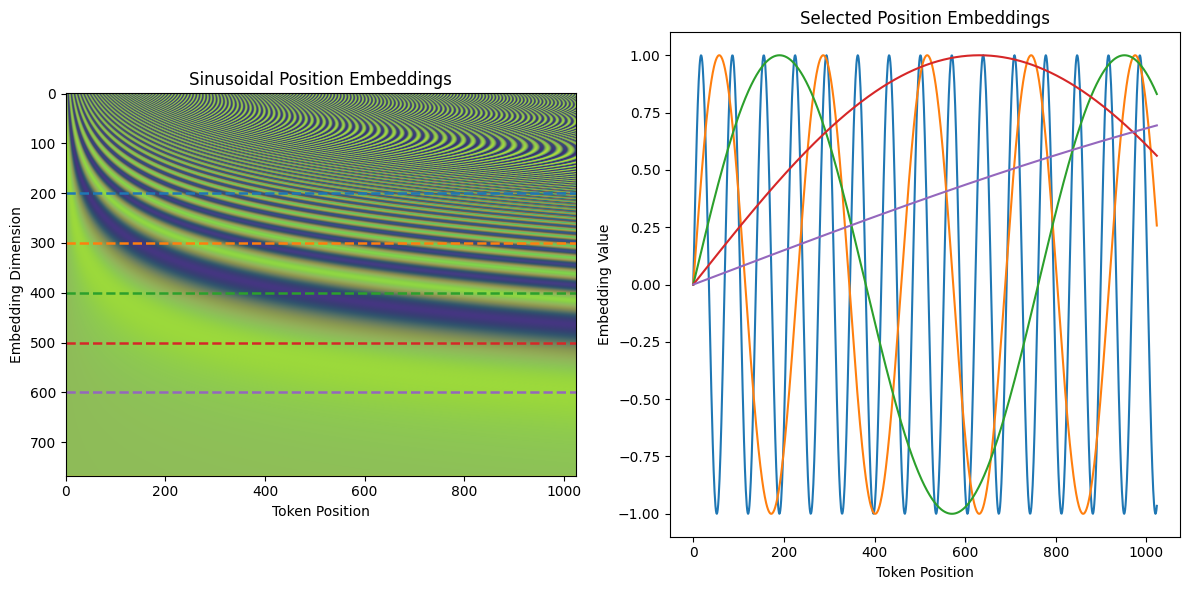

In [ ]:
# another approach different to training the embeddings from data like in GPT2 is to create a bunc of sine and cosine waves of different frequencies, 
# which is what the original transformer paper did.

positions_formula = np.zeros_like(position_embeddings)
num_dimensions = position_embeddings.shape[1]

# token position ("time")
token_positions = np.arange(position_embeddings.shape[0]) # array(0, 1, 2, ..., 1023)

for i in range(0, num_dimensions, 2):
    denominator = 10000 ** (i / num_dimensions)
    positions_formula[:, i] = np.sin(token_positions / denominator)
    positions_formula[:, i + 1] = np.cos(token_positions / denominator)

# visualize the matrix
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(positions_formula.T, cmap='viridis', vmin=-1, vmax=1)
axs[0].set_title('Sinusoidal Position Embeddings')
axs[0].set_xlabel('Token Position')
axs[0].set_ylabel('Embedding Dimension')

positions_to_show = [200, 300, 400, 500, 600]
h = axs[1].plot(positions_formula[:, positions_to_show])
axs[1].set_title('Selected Position Embeddings')
axs[1].set_xlabel('Token Position')
axs[1].set_ylabel('Embedding Value')

for i, p in enumerate(positions_to_show):
    axs[0].axhline(p, color=h[i].get_color(), linestyle='--', linewidth=1.8)
plt.tight_layout()
plt.show()

# now the position embeddings are way more regular and smooth, and they have a clear pattern of low to high frequency waves. 
# This is because they are generated by a deterministic formula, rather than being learned from data.